In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, chi2, SelectKBest
from sklearn.linear_model import LogisticRegression

In [14]:
data_path = "../data/heart_disease_cleaned.csv"
df = pd.read_csv(data_path)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0.949794,0.682656,1.976470,0.764066,-0.261285,2.389793,-1.002541,0.018826,-0.698344,1.084022,-2.271182,-0.714911,-2.147955,0.917313
1,-1.928548,0.682656,1.005911,-0.091401,0.067741,-0.418446,0.901657,1.636979,-0.698344,2.118926,-2.271182,-0.714911,-0.513994,0.917313
2,-1.485726,-1.464866,0.035352,-0.091401,-0.822564,-0.418446,-1.002541,0.980971,-0.698344,0.307844,0.979514,-0.714911,-0.513994,0.917313
3,0.174856,0.682656,0.035352,-0.661712,-0.203222,-0.418446,0.901657,1.243374,-0.698344,-0.209608,0.979514,-0.714911,-0.513994,0.917313
4,0.285561,-1.464866,-0.935208,-0.661712,2.080602,-0.418446,0.901657,0.587366,1.431958,-0.382092,0.979514,-0.714911,-0.513994,0.917313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,0.285561,-1.464866,-0.935208,0.478910,-0.106449,-0.418446,0.901657,-1.161988,1.431958,-0.727060,-0.645834,-0.714911,1.119967,-1.090140
298,-1.042904,0.682656,1.976470,-1.232023,0.338703,-0.418446,0.901657,-0.768384,-0.698344,0.135360,-0.645834,-0.714911,1.119967,-1.090140
299,1.503322,0.682656,-0.935208,0.707035,-1.035462,2.389793,0.901657,-0.374779,-0.698344,2.032684,-0.645834,1.274980,1.119967,-1.090140
300,0.285561,0.682656,-0.935208,-0.091401,-2.235438,-0.418446,0.901657,-1.511859,1.431958,0.135360,-0.645834,0.280034,1.119967,-1.090140


In [15]:
X = df.drop(columns=["target"])
y = df["target"].astype(int)

In [17]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

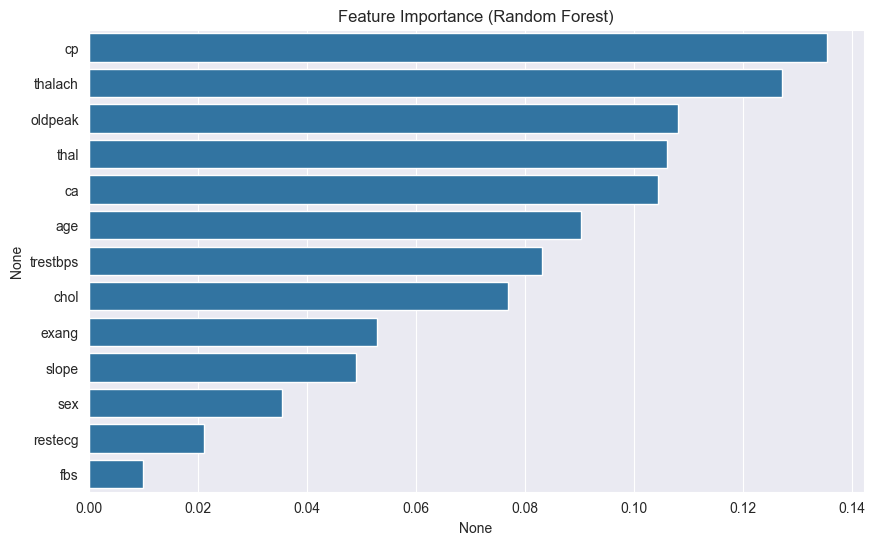

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [20]:
logreg = LogisticRegression(max_iter=1000, solver="liblinear")
rfe = RFE(logreg, n_features_to_select=5)
rfe.fit(X, y)

rfe_selected = X.columns[rfe.support_].tolist()
print(rfe_selected)

['sex', 'cp', 'thalach', 'oldpeak', 'ca']


In [21]:
chi_selector = SelectKBest(score_func=chi2, k=5)
X_chi = chi_selector.fit_transform(X.abs(), y)
chi_selected = X.columns[chi_selector.get_support()].tolist()
print(chi_selected)

['sex', 'exang', 'oldpeak', 'ca', 'thal']


In [22]:
selected_features = list(set(
    rfe_selected + chi_selected + importances.head(5).index.tolist()
))
print(selected_features)

['exang', 'ca', 'thal', 'thalach', 'oldpeak', 'cp', 'sex']


In [23]:
X_selected = X[selected_features]
df_selected = pd.concat([X_selected, y], axis=1)

In [24]:
df_selected.to_csv("../data/heart_disease_selected.csv", index=False)
